In [ ]:
#Installing necessary packages in virutal environment
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scipy
%pip install itertools

# Introduction

The goal of this project is to analyze biodiversity data from the National Parks Service, particularly around various species observed in different national park locations.

This project will scope, analyze, prepare, plot data, and seek to explain the findings from the analysis.

Here are the questions that this project will attempt to answer:

- What is the distribution of the conservation status for species?
- Are certain types of species more likely to be endangered?
- Are the differences between species and their conservation status significant?
- Which animal is most prevalent and what is their distribution amongst parks?

**Data Sources:**

Both `Observations.csv` and `Species_info.csv` was provided by [Codecademy.com](https://www.codecademy.com).

Note: The data for this project is *inspired* by real data, but is mostly fictional.

## Scoping

Four sections below have been created to help guide this project's process and progress. The first section is the Project Goals, which will define the objectives and set the intentions of this project as a whole. Next, we will define the Data section, in which we will check to see if the given data sets are able to help us meet our defined project goals. Thirdly, we will have our Analysis section which will include the methods and questions aligned with our stated project goals. Lastly, we will have our Evaluation section where we will deliver our conclusions and findings upon the completion of our data analysis.

### Project Goals

In this project, we will imagine ourselves to be a biodiversity analyst hired by the National Park Service. The National Park Service has a goal to ensure the survival and prosperity of at-risk and endangered species residing in their parks, to not only protect these species, but to ensure that there is dense level of biodiversity within thier parks as well. With this in mind, our main objectives as a hired analyst will be to understand some key characteristics of each species along with their conservation status, as well as to understand each species and thier relationship to the national parks. Here are some questions which will help us to uncover these findings (same as previous):

- What is the distribution of conservation status for species?
- Are certain species more likely to be endangered?
- Are the differences between species and thier conservation status significant?
- Which animal is most prevalent and what is thier distribution amongst parks?

### Data

This project will conduct analysis using two data sets:

- `Species_info.csv` contains information regarding each species
- `Obervations.csv` contains information regarding the observation of species within each park location

### Analysis 

In this section, descriptive statistics and data visualization techniques will be employed to better understand out data. Statistical inference will also be used in order to test if observed values are statisticall significant. Key metrics that will be computed include:

1. Distributions
1. Counts
1. Relationships Between Species
1. Conservation Status of Species
1. Observation of Species in Parks

### Evaluation

In this section, we will revisit the stated goals and confirm that our analysis of the data is in alignment with the answers to the initial questions posed within our project (Goals section). This section will also refelct on our findings, as well as disclose if any of our initial questions were unable to be answered. This will also include limitations or is any of the analysis could have been done using different methodologies.

## Importing Python Modules

Import the necessary python modules that will be used in this project:

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Loading the Data

To analyze the status of conservation of species and their observations in national parks, we first load the datasets into pandas `DataFrames`. Once this has been done, we can then begin to analyze and visualize our data.

In the following lines of code, `Observations.csv` and `Species_info.csv` are read in as `DataFrames` called `observations` and `species` respectively. We then use the `.head()` method on each of our `DataFrames` to check the contents of the first five rows of data in each table.

#### Species

The `species_info.csv` contains information on the different species found in the national parks. The columns include:
- **category** - The category taxonomy for each species
- **scientific_names** - The scientific name of each species
- **common_names** - The common names of each species
- **conservation_status** - The species conservation status

In [ ]:
species = pd.read_csv('species_info.csv', encoding='utf-8')
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


#### observations

The `Observations.csv` contains information from recorded sightings of different species throughout the national parks in the last 7 days. The columns include:

- **scientific_name** - The scientific name of each species
- **park_name** - The name of the national park
- **observations** - The number of observations in the past 7 days

In [4]:
observations = pd.read_csv('observations.csv', encoding='utf-8')
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


#### Data Characteristics

Following the display of the first 5 rows of data within each dataset, I will perform a dimension check on each dataset. When this is performed, we can see that the `species` dataset contains 5,824 rows with 4 columns, while the `observations` dataset contains 23,296 rows with 3 columns.

In [5]:
print(f"Species Dimensions: {species.shape}")
print(f"Observations Dimensions: {observations.shape}")

Species Dimensions: (5824, 4)
Observations Dimensions: (23296, 3)


## Explore the Data

To begin exploring our datasets further, we will first begin by finding the number of distinct species within our `species` dataset. To perform this, we will use the `scientific_name` column which will produce 5,541 uniques species throughout the national parks.

In [6]:
print(f"Number of Unique Species: {species.scientific_name.nunique()}")

Number of Unique Species: 5541


The next thing that we are going to do is find out just how many categories are represented in the `category` column of our `species` dataset. When we perform this, we find that there are 7 unique categories consisting of both different plant and animal types.

In [7]:
print(f"Number of Categories: {species.category.nunique()}")
print(f"Categories: {species.category.unique()}")

Number of Categories: 7
Categories: ['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']


In addition to this initial analysis, we can actually drill a bit deeper into this `category` column. Here, we can use the `groupby()` function on the `category` column to see the full count of each category in the dataset. When this is performed, we can see that Vascular plants are the largest proportion of species with 4,470 logged into the dataset, and we can also see that Reptiles make up the smallest proportion with 79 logged entries.

In [8]:
species.groupby("category").size()

category
Amphibian              80
Bird                  521
Fish                  127
Mammal                214
Nonvascular Plant     333
Reptile                79
Vascular Plant       4470
dtype: int64

Next in our data exploration, we will begin to analyze the `conservation_status` column in our species dataset. This column contains 4 categories: `Species of Concern`, `Endangered`, `Threatened`, and `In Recovery`. It is also important to note that this column does also contain some null values in the form of `nan`.

In [9]:
print(f"Number of Conservation Statuses: {species.conservation_status.nunique()}")
print(f"Unique Conservation Statuses: {species.conservation_status.unique()}")

Number of Conservation Statuses: 4
Unique Conservation Statuses: [nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


Next, much like we did previously with the `category` column, we will drill one level deeper into the `conservation_status` column to see the full count within each category within this column. Upon perfroming this, we will see that there are 5,633 `nan` values, 161 species of concern, 16 species that are endangered, 10 species that are threatened, and then 4 species in recovery. 

It is also important to note that our `nan` values in this context represent a recorded species that does not meet the criterium of being concerened, endangered, threatened, or currently in recovery.

In [10]:
print(f"nan values: {species.conservation_status.isna().sum()}")

print(species.groupby("conservation_status").size())

nan values: 5633
conservation_status
Endangered             16
In Recovery             4
Species of Concern    161
Threatened             10
dtype: int64


#### Observations

In this next section, we will begin to analyze the `observations` dataset. In this first step, we will determine the number of national parks in our dataset, as well as the names of those parks.

In [11]:
print(f"Number of Parks: {observations.park_name.nunique()}")
print(f"Park Names: {observations.park_name.unique()}")

Number of Parks: 4
Park Names: ['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


Next, we will look at the total number of observations logged in each park within the last 7 days, as well as how many observations have occured within each park.

In [12]:
print(f"Total Number of Observations: {observations.observations.sum()}")

print(observations.groupby("park_name").size())

Total Number of Observations: 3314739
park_name
Bryce National Park                    5824
Great Smoky Mountains National Park    5824
Yellowstone National Park              5824
Yosemite National Park                 5824
dtype: int64


## Analysis

To begin our extended analysis, first we will clean the `conservation_status` column in the `species` dataset in order to explore that column further.

As previoulsy noted, the `conservation_status` column has several possible values:
- `Species of Concern`: Population of the species is in decline, appears to need to be under conservation
- `Threatened`: Possibility to be Endangered in the near future
- `Endangered`: Species is at a high risk for extinction
- `In Recovery`: formerly `Endangered`, but now currently not at risk for extinction

In addition to this, we will need to change the `nan` values to `No Intervention`.

In [13]:
species.fillna('No Intervention', inplace=True)
species.groupby("conservation_status").size()

conservation_status
Endangered              16
In Recovery              4
No Intervention       5633
Species of Concern     161
Threatened              10
dtype: int64

Next, we will drill deeper into the `conservation_status` column in order to see what sort of species are nested into each category of the column. This will only include species that do require a conservation intervention.

When looking at the more extreme categories such as `Endangered` and `In Recovery` we can see that for those carrying a status of `Endangered`, 4 were birds and 7 were mammals. However, for those species carrying a label of `In Recovery`, 3 were birds while there was only 1 mammal. This could suggest that birds are recovering better than mammals in a general sense.

In [14]:
conservationCategory = species[species.conservation_status != "No Intervention"]\
    .groupby(["conservation_status", "category"])['scientific_name']\
    .count()\
    .unstack()

conservationCategory

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
conservation_status,,,,,,,
Endangered,1.0,4.0,3.0,7.0,NaN,NaN,1.0
In Recovery,NaN,3.0,NaN,1.0,NaN,NaN,NaN
Species of Concern,4.0,72.0,4.0,28.0,5.0,5.0,43.0
Threatened,2.0,NaN,4.0,2.0,NaN,NaN,2.0


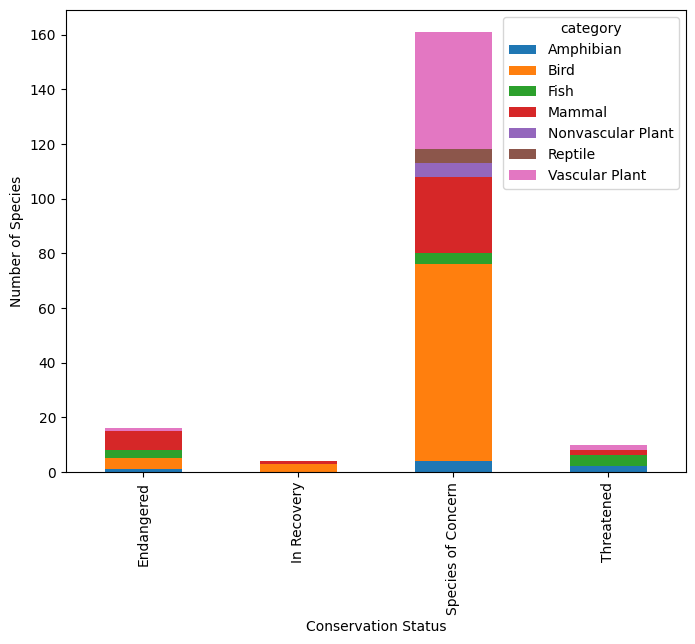

In [15]:
ax = conservationCategory.plot(kind = 'bar', figsize=(8,6), 
                               stacked=True)
ax.set_xlabel("Conservation Status")
ax.set_ylabel("Number of Species");

#### In Conservation

Another question that we want to investigate is "Are certain types of species more likely to be endangered?" We can answer this question by creating a new column called `is_protected` and including all species that have a value other than `No Intervention`.

In [32]:
species['is_protected'] = species.conservation_status != "No Intervention"

Next, we group by `category` and `is_protected` and then inspect the results of our question.

Through this inspection, we can see that Birds, Vascular Plants, and Mammals have a higher number of species protected.

In [35]:
category_counts = species.groupby(['category', 'is_protected'])\
                        .scientific_name.nunique()\
                        .reset_index()\
                        .pivot(columns='is_protected', 
                               index='category', 
                               values='scientific_name')\
                        .reset_index()
category_counts.columns = ['category', 'not_protected', 'protected']

category_counts

,category,not_protected,protected
0,Amphibian,72,7
1,Bird,413,75
2,Fish,115,11
3,Mammal,146,30
4,Nonvascular Plant,328,5
5,Reptile,73,5
6,Vascular Plant,4216,46


While the absolute numbers in the chart are a good start, we should also make sure that we calculate the rate of protection for each category in the data. When we do this, we can see that ~17 percent of mammals are under protection, as well as ~15 percent of birds.

In [36]:
category_counts['pct_protected'] = category_counts.protected / \
                                (category_counts.protected + category_counts.not_protected) * 100

category_counts


,category,not_protected,protected,pct_protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


#### Statistical Significance

In this section, we will run chi-squared tests in order to see if differnet species have statistically significant differences in their conservation status rates. 

Note: A "chi-squared" test is a statistical tool used to determine if two categorical variables are indepoendent or unrelated. It does this through comparing observed values to expected values to determine if the differnece in those values is statistically significant

First, we will need to create a contingency table that will look as followed:

||protected|not protected|
|-|-|-|
|Mammal|?|?|
|Bird|?|?|

Our first contingency table will be called `mb_contingency`, and we will use it to see if there is a significant relationship between mammals and birds.

When our results are returned, we notice that the chi-squared tests returns two values and an array. The second value that is returned is the p-value, which is 0.69 in this case. Standard p-values that we may attribute to significance would be 0.1, 0.05, and 0.01. Here, we can see that this p-value is much larger than all of those standard values, meaning that there does not seem to be any significant relationship between mammals and birds.

In [37]:
from scipy.stats import chi2_contingency

mb_contingency = [[30, 146],
                  [75, 413]]
chi2_contingency(mb_contingency)

Chi2ContingencyResult(statistic=np.float64(0.1617014831654557), pvalue=np.float64(0.6875948096661336), dof=1, expected_freq=array([[ 27.8313253, 148.1686747],
       [ 77.1686747, 410.8313253]]))

Next, we will create another contingency table in order to perform another chi-squared test between `Reptile` and `Mammal`.

||protected|not protected|
|-|-|-|
|Mammal|?|?|
|Reptile|?|?|

When our results are returned this time, we can see that the p-value is 0.039. With this result under a 0.1 and a 0.05 significance threshold, we can say that there is a statistically significant difference between reptiles and mammals when it comes to needing protection. In this case, Mammals are proven to have statistically significant higher rates of needed protection when being compared to reptiles.

In [38]:
mr_contingency = [[30, 146], 
                  [5, 73]]
chi2_contingency(mr_contingency)

Chi2ContingencyResult(statistic=np.float64(4.289183096203645), pvalue=np.float64(0.03835559022969898), dof=1, expected_freq=array([[ 24.2519685, 151.7480315],
       [ 10.7480315,  67.2519685]]))

#### Species in Parks

In this next section of analysis, we will be analyzing data recorded from the conservationists in the form of recorded sightings of different species within each of the national parks over the last 7 days.

First, we will look at all of the common names mentioned in the `species` dataset to observe which animals are most accounted for within the dataset.

Note: The data will need to be split into the individual names, removing any additional punctuation in the original data entries.

In [39]:
from itertools import chain
import string

def remove_punctuations(text):
    for punctuation in string.punctuation:
        text = text.replace(punctuation, '')
    return text

common_Names = species[species.category == "Mammal"]\
    .common_names\
    .apply(remove_punctuations)\
    .str.split().tolist()

common_Names[:6]

[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison', 'Bison'],
 ['Aurochs',
  'Aurochs',
  'Domestic',
  'Cattle',
  'Feral',
  'Domesticated',
  'Cattle'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Sheep', 'Sheep', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

Next, we need to rid the the previous output of any duplicate values found in any of the rows. This is due to the fact that here, we do not want each species to be counted more than once.

In [40]:
cleanRows = []

for item in common_Names:
    item = list(dict.fromkeys(item))
    cleanRows.append(item)

cleanRows[:6]

[['Gappers', 'RedBacked', 'Vole'],
 ['American', 'Bison'],
 ['Aurochs', 'Domestic', 'Cattle', 'Feral', 'Domesticated'],
 ['Domestic', 'Sheep', 'Mouflon', 'Red', 'Feral'],
 ['Wapiti', 'Or', 'Elk'],
 ['WhiteTailed', 'Deer']]

Finally, we can make a small adjustment to make sure that the following common names are more legible. We can do this through collapsing all of the words into one list.

In [41]:
res = list(chain.from_iterable(i if isinstance(i, list) else [i] for i in cleanRows))
res[:6]

['Gappers', 'RedBacked', 'Vole', 'American', 'Bison', 'Aurochs']

Now in this format, the data is prepared appropriately in order to count the total number of occurences of each common name.

In this analysis, we can see that `Shrew` had 18 occurences and `Bat` had 23 occurences.

In [42]:
words_counted = []

for i in res:
    x = res.count(i)
    words_counted.append((i,x))

pd.DataFrame(set(words_counted), columns = ['Word', 'Count']).sort_values("Count", ascending = False).head(10)

,Word,Count
162,Bat,23
40,Shrew,18
49,Myotis,17
196,Mouse,16
6,Chipmunk,13
199,American,12
54,Squirrel,12
43,Eastern,11
57,Vole,11
147,Western,10


While we have concluded that the occurence of `Bat` is the most frequent, there are still several different scientific names for different types of bats. So, our next task should be to find out which rows in our `species` dataset are referring to bats.

To do this, we can add a column of boolean values to check if `is_bat` is equal to `True`.

In [43]:
species['is_bat'] = species.common_names.str.contains(r"\bBat\b", regex = True)

species.head(10)

,category,scientific_name,common_names,conservation_status,projected,is_bat,is_protected
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,No Intervention,False,False,False
1,Mammal,Bos bison,"American Bison, Bison",No Intervention,False,False,False
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",No Intervention,False,False,False
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",No Intervention,False,False,False
4,Mammal,Cervus elaphus,Wapiti Or Elk,No Intervention,False,False,False
5,Mammal,Odocoileus virginianus,White-Tailed Deer,No Intervention,False,False,False
6,Mammal,Sus scrofa,"Feral Hog, Wild Pig",No Intervention,False,False,False
7,Mammal,Canis latrans,Coyote,Species of Concern,True,False,True
8,Mammal,Canis lupus,Gray Wolf,Endangered,True,False,True
9,Mammal,Canis rufus,Red Wolf,Endangered,True,False,True


This next portion of code displays the the subset of data to where `is_bat` is equal to `True`. 

There seem to be many different species of bat, and there is a fair mix between protected and not protected species.

In [44]:
species[species.is_bat]

,category,scientific_name,common_names,conservation_status,projected,is_bat,is_protected
28,Mammal,Corynorhinus rafinesquii,Rafinesque's Big-Eared Bat,No Intervention,False,True,False
29,Mammal,Eptesicus fuscus,Big Brown Bat,Species of Concern,True,True,True
30,Mammal,Lasionycteris noctivagans,Silver-Haired Bat,Species of Concern,True,True,True
31,Mammal,Lasiurus borealis,"Eastern Red Bat, Red Bat",No Intervention,False,True,False
32,Mammal,Lasiurus cinereus,Hoary Bat,No Intervention,False,True,False
36,Mammal,Myotis leibii,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,True,True,True
37,Mammal,Myotis lucifugus,"Little Brown Bat, Little Brown Myotis",Species of Concern,True,True,True
38,Mammal,Myotis septentrionalis,"Northern Long-Eared Bat, Northern Myotis",Threatened,True,True,True
39,Mammal,Myotis sodalis,"Indiana Bat, Indiana Or Social Myotis",Endangered,True,True,True
40,Mammal,Nycticeius humeralis,Evening Bat,No Intervention,False,True,False


Next, we can merge the results of our bat species subset with our `observations` dataset in order to create a `DataFrame` with observations of each bat across the four national parks that we are investigating.

In [45]:
bat_observations = observations.merge(species[species.is_bat])
bat_observations

,scientific_name,park_name,observations,category,common_names,conservation_status,projected,is_bat,is_protected
0,Lasiurus blossevillii,Bryce National Park,113,Mammal,Western Red Bat,Species of Concern,True,True,True
1,Corynorhinus rafinesquii,Yosemite National Park,188,Mammal,Rafinesque's Big-Eared Bat,No Intervention,False,True,False
2,Nycticeius humeralis,Yellowstone National Park,219,Mammal,Evening Bat,No Intervention,False,True,False
3,Lasiurus blossevillii,Great Smoky Mountains National Park,70,Mammal,Western Red Bat,Species of Concern,True,True,True
4,Lasiurus borealis,Yosemite National Park,134,Mammal,"Eastern Red Bat, Red Bat",No Intervention,False,True,False
...,...,...,...,...,...,...,...,...,...
139,Eptesicus fuscus,Bryce National Park,72,Mammal,Big Brown Bat,Species of Concern,True,True,True
140,Eptesicus fuscus,Bryce National Park,72,Mammal,"Big Brown Bat, Big Brown Bat",Species of Concern,True,True,True
141,Myotis leibii,Yellowstone National Park,233,Mammal,"Eastern Small-Footed Bat, Eastern Small-Footed...",Species of Concern,True,True,True
142,Lasionycteris noctivagans,Bryce National Park,128,Mammal,Silver-Haired Bat,Species of Concern,True,True,True


Now we are able to investigate how many total bat observations have been recorded across the four national parks.

In the table below, the total number of bats observed across each of our four national parks from the last 7 days will be displayed. From this table, we are able to see that Yellowstone National Park has the largest amount of recorded observations with 8,362, while Great Smoky Mountains National Park has the lowest amount of recorded observations with 2,411.

In [46]:
bat_observations.groupby('park_name').observations.sum().reset_index()

,park_name,observations
0,Bryce National Park,3433
1,Great Smoky Mountains National Park,2411
2,Yellowstone National Park,8362
3,Yosemite National Park,4786


To further investigate this data, we can drill deeper to visualize each park broken down by protected vs. non-protected bat sightings.

Within our findings, we are able to see that in every park besides Great Smoky Mountains National Park, there are more sightings of protected bats as opposed to non-protected bats. This may symbolize that protected species of bats are doing well in thier conservation efforts.

In [47]:
obs_by_park = bat_observations.groupby(['park_name', 'is_protected']).observations.sum().reset_index()
obs_by_park

,park_name,is_protected,observations
0,Bryce National Park,False,1596
1,Bryce National Park,True,1837
2,Great Smoky Mountains National Park,False,1299
3,Great Smoky Mountains National Park,True,1112
4,Yellowstone National Park,False,4044
5,Yellowstone National Park,True,4318
6,Yosemite National Park,False,2345
7,Yosemite National Park,True,2441


Below is a plot from the table output above. 

Much like the inferences that we have made within out table data, we can see that Yellowstone National Park and Bryce National Park seem to be doing well in their convervation of protected species of bats due to the fact that there are more sightings of protected species of bats compared to non-protected species of bats.

We can also see that Great Smoky Mountains National Park is not doing as well as the former two parks mentioned due to the fact that there are more sightings of non-protected species of bats compared to protected species of bats.

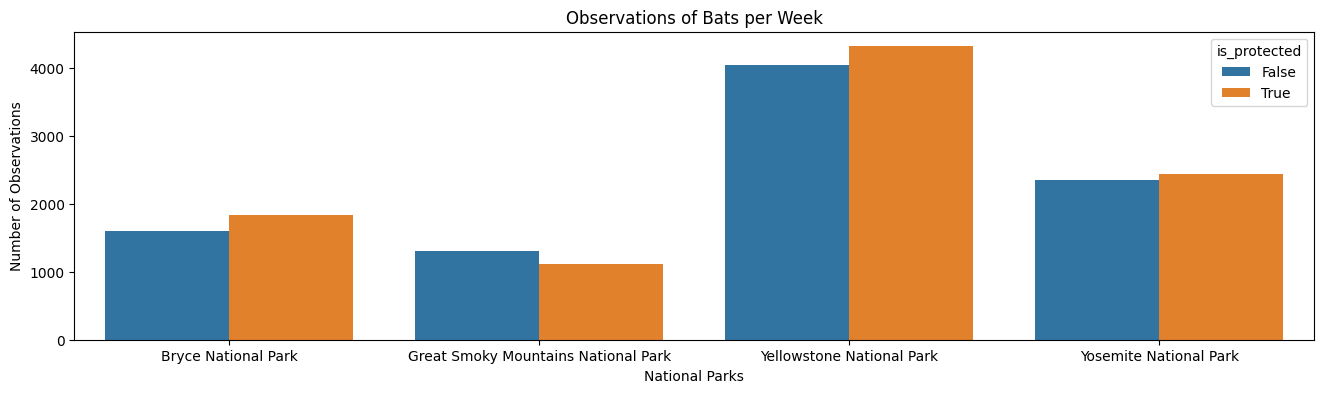

In [48]:
plt.figure(figsize=(16, 4))
sns.barplot(x = obs_by_park.park_name, y = obs_by_park.observations, hue = obs_by_park.is_protected)
plt.xlabel('National Parks')
plt.ylabel('Number of Observations')
plt.title('Observations of Bats per Week')
plt.show()

## Conclusions

Over the course of this project, we were able to answer some of the questions posed when we first started our analysis:

- What is the distribution of conservation status for species?
    - The majority of the observed species were not part of any conservation efforts. (5,633 vs 191)
- Are certain types of species more likely to be endangered?
    - Mammals and Birds were found to have the largest amount of species involved in conservation efforts.
- Are the differences between species and thier conservation status significant?
    - Mammals and Reptiles did exhibit a statistically significant difference in their conservation percentage, while Mammals and Birds did not have a statistically significant difference in their conservation percentage.
- Which animal is most prevalent and what is their distribution amongst the parks?
    - Our analysis found species of Bats to be the most prevalent group of species, and they were most likely to be found in Yellowstone National Park.

## Further Research

This dataset only had data from a 7 day period, which was a limitaion on doing any sort of time-series analysis. In addition to this, the land area of each of the parks was not included in the dataset. Without this information, it is only assumed that Yellowstone National Park is much larger than the other three national parks, and can again only be assumed, that this would cause Yellowstone to exhibit more observations and greater biodiversity. To finish, if precise locations of each sighting were recorded within each of the parks, we may have been able to observe the spatial distribution of the species, allowing us to test if these observations are or are not spatiall clustered.